(sec:FCS)=
# Full counting statistics

Following Glauber's definition of photons, our focus is on the photons detected by the measurement device.  The detector only records the time of clicks for a certain period of time.  After detecting $N$ photons, we have a time series $\{t_{1}, t_{2}, \cdots, t_{N} \}$.  A question is what information we can get out of the time series.  In this section, we introduce some statistical methods to analyze such data.

## Instantaneous and mean counting rates

An obvious information is the number of photons per a unit time or counting rate.  If $\Delta N$ photons are detected during a small time interval $\Delta t$ around time $t$ (or more precisely a period $[t,t+\Delta t]$), the counting rate is given by $\lambda(t) = \Delta N/\Delta t$, which is assumed to be proportional to the intensity of light.  The counting rate fluctuates around the mean $\lambda = \frac{1}{t_\text{max}} \int_{0}^{t_\text{max}} \lambda(t) dt$.  Some interesting features of quantum light can be seen in the fluctuation of the counting rate, which we discuss next.

## Three types of waiting time distribution

We are interested in the time intervals between two successive arrivals of photons, which is known as waiting time.  The statistical distribution of the intervals tells us the certain characters of the light. In this section, we discuss three different types of waiting time distribution using a simple statistical model known as Gamma renewal processes (not based on physics of photons). Since this model is often used in neuroscience, we shall call the clicks of the detector "spikes".

1. Poisson distribution:   Spikes arrive independently at a constant average rate. The variance in its intensity equals the mean squared.
2. Super-poissonian distribution:  Photons tend to arrive together in bunch during a short period of time (bunching) but it takes a longer time before a next bunch arrive. Statistically a variance of the intensity is larger than the mean squared.
3. Sub-poissonian distribution: Photons arrive more regularly than random (antibunching), resulting in a variance smaller than the mean squared.

As an example, we consider three different distributions and plot corresponding time series using the Gamma renewal process.  Consider a Gamma distribution

$$
p(\tau) = \frac{1}{\Gamma(k)} \lambda^k \tau^{k-1} e^{(-\lambda \tau)}
$$

where $\Gamma(\cdot)$ is the Gamma function.    The mean and variance are 

$$
\langle \tau \rangle = \frac{k}{\lambda}
$$

and 

$$
(\Delta \tau)^2 = \langle \tau^2 \rangle = \frac{k}{\lambda^2}.
$$

The ratio of variance to the mean squared is $1/k$ and thus the the fluctuation is larger for smaller $k$.
When $k=1$, the fluctuation and the mean coincides and thus we have poisson distribution.  The distributionis super-Poissonian  for $k<1$ and sub-Poissonian for $k>1$.  

In the following figure, three distributions with $k=1$, $k=0.5$, and $k=2.0$ are plotted.  $\lambda$ is chosen such that all distribution have the same mean value (dashed line) so that the width of the distribution (fluctuation) can be compared.


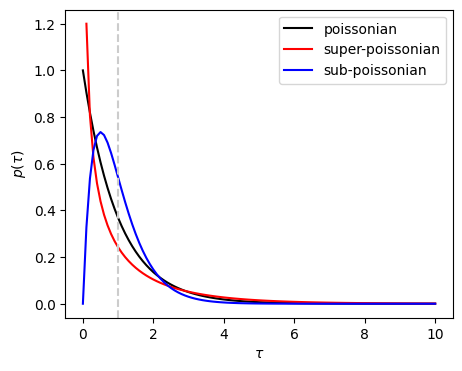

In [153]:
import numpy as np
import matplotlib.pyplot as plt


# all three distributions have the same mean value
mean=1

# poisson distribution k=1
def dist_poisson(tau):
    lam = 1/mean
    return lam * np.exp(-lam*tau)

# subpoisson distribution k=2
def dist_subpoisson(tau):
    k=2
    lam = k/mean
    return lam**k * tau**(k-1) * np.exp(-lam*tau)

# superpoisson distribution k=1/2
def dist_superpoisson(tau):
    lam = 0.5/mean
    tau[0]=1  # avoid divide by zero error
    dist = lam**0.5 / tau**0.5 * np.exp(-lam*tau)/np.sqrt(np.pi)
    dist[0]=np.inf  # infinity at tau=0
    tau[0]=0  # reset tau[0]
    return dist
    
tau = np.linspace(0,10,101)


poisson = dist_poisson(tau)
subpoisson = dist_subpoisson(tau)
superpoisson = dist_superpoisson(tau)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(tau,poisson,'k',label="poissonian")
ax.plot(tau,superpoisson,'r',label="super-poissonian")
ax.plot(tau,subpoisson,'b',label="sub-poissonian")
ax.legend(loc=1)
ax.axvline(x = 1, color = '0.8', linestyle = '--')
ax.set_xlabel(r"$\tau$")
ax.set_ylabel(r"$p(\tau)$")
plt.show(fig)


In the above plot, notice that $p(0)=0$ for the subpoissonian distribution. That means the chance that two photons arrive at the same time is null.  On the other hand, the superpoissonian distribution has $\lim_{\tau\rightarrow 0}p(\tau) = \infty$, suggesting that the chance of two or more photons arriving at the same time is high.  In between, the poisson distribution has $p(0)=1$.

The spike plots in the following figure shows simulated arrival times of photons at the detector using the above three distributions.

## Bunching and Anti-bunching

We try to visualize what we found in the previous section. The arrival time of photons are simulated with the Gamma renewal processes.  In the following plots, the arrival of a photon is plotted as a spike. The same parameter values is used as in the above plot.  About 100 photons are detected for each probability distribution but since the process is stochastic it varies from one run to another.   

In [154]:
import numpy as np
import matplotlib.pyplot as plt

# reset random number
rng = np.random.default_rng()

# generate spike train
def spike_train(tmax, mean, k):

    lam = k/mean

    times = np.array([])

    t = 0.0
    while True:
        tau = rng.gamma(shape=k, scale=1/lam)
        t += tau
        if t >= tmax:
            break
        times = np.append(times,t)
    return times    

tmax = 100
spikes_poisson = spike_train(tmax,1,1)
spikes_subpoisson = spike_train(tmax,1,3)
spikes_superpoisson = spike_train(tmax,1,0.5)

print("The number of photons detected during time period of ",tmax)
print("  sub-poisson =",spikes_subpoisson.size)
print("      poisson =",spikes_poisson.size)
print("super-poisson =",spikes_superpoisson.size)

The number of photons detected during time period of  100
  sub-poisson = 95
      poisson = 93
super-poisson = 112


Next we plot the spikes of photons for three types of probability distributions.

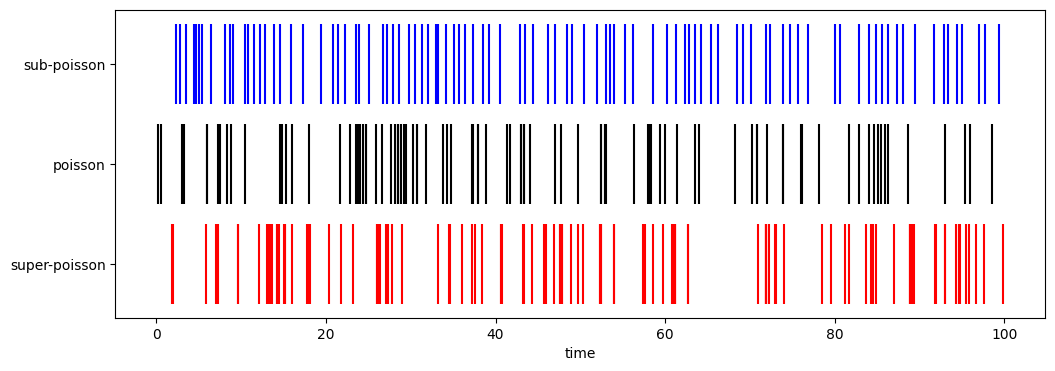

In [155]:
# plot the results
fig, ax = plt.subplots(figsize=(12, 4))
ax.vlines(spikes_subpoisson, 2.6, 3.4, color='b', label="k=2")
ax.vlines(spikes_poisson, 1.6, 2.4, color='k', label="k=1")
ax.vlines(spikes_superpoisson, 0.6, 1.4, color='r', label="k=1/2")
ax.set_yticks([1, 2, 3])
ax.set_yticklabels(["super-poisson", "poisson", "sub-poisson"])
ax.set_xlabel("time")
plt.show(fig)

Roughly speaking the spikes are spread evenly for the sub-poissonian distribution, indicating that photons arrive constantly with little fluctuation.  For super-poissonian distribution, on the other hand, wide gaps between spikes can be seen and photons tend to arrive together in clusters .  Since photons in coherent laser is known to obey the poisson distribution, we consider it as a reference.  The tendency that photons in the super-poissonian distribution arrive together in clusters with respect to photons in  the poisson distribution is known as _photon bunching_.  In the opposite direction, the tendency that photons in the sub-poissonian distribution arrive constantly is called _photon anti-bunching_.

[^note_mode]: A single mode of photons is defined as a specific quantum state of the electromagnetic field characterized by a unique, discrete spatial structure, polarization, and frequency or a precise superpostion of frequencies.

## Data analysis

In experiments, we obtain the time series.  In this section, we discuss how to extract the type of statistics from the observed data.  WE will use these statistical methods in the following chapters.

###  Waiting time distribution

Suppose we have a time sequence $\{t_{i}, i=1,\cdots, N\}$. We generate the corresponding waiting time sequence $\{\tau_i = t_{i+1}-t_{i}\}$ and plots it as a histogram.  The following code calculate the three types obtained by the above codes (we need larger data set to reduce statistical errors.)   Compare the mean value $\lambda$ and fluctuation $\Delta \lambda$.

In [156]:
# continued from the previous code block.
# run it before this code block.

# increase the measurement period.

tmax = 1000
spikes_poisson = spike_train(tmax,1,1)
spikes_subpoisson = spike_train(tmax,1,3)
spikes_superpoisson = spike_train(tmax,1,0.5)

def waiting_time(spikes):
    N_spikes = len(spikes)
    wtime = np.array([])
    for i in range(N_spikes-1):
        wtime = np.append(wtime,spikes[i+1]-spikes[i])
    return wtime

wtime_poisson = waiting_time(spikes_poisson)
wtime_subpoisson = waiting_time(spikes_subpoisson)
wtime_superpoisson = waiting_time(spikes_superpoisson)

mean_poisson = sum(wtime_poisson)/len(wtime_poisson)
mean_superpoisson = sum(wtime_superpoisson)/len(wtime_superpoisson)
mean_subpoisson = sum(wtime_subpoisson)/len(wtime_subpoisson)

dev_poisson = np.sqrt(sum(wtime_poisson**2)/len(wtime_poisson) - mean_poisson**2)
dev_superpoisson = np.sqrt(sum(wtime_superpoisson**2)/len(wtime_superpoisson) - mean_superpoisson**2)
dev_subpoisson = np.sqrt(sum(wtime_subpoisson**2)/len(wtime_subpoisson) - mean_subpoisson**2)

print("waiting time statistics")
print('  sub-poisson: λ=', mean_subpoisson, 'Δλ=', dev_subpoisson)
print('      poisson: λ=', mean_poisson,    'Δλ=', dev_poisson)
print('super-poisson: λ=', mean_superpoisson, 'Δλ=', dev_superpoisson)



waiting time statistics
  sub-poisson: λ= 0.9798159344774297 Δλ= 0.5886070826194967
      poisson: λ= 0.9942299164967543 Δλ= 1.0238800086296598
super-poisson: λ= 1.0340933784976285 Δλ= 1.4612401817354803


Now, e plot the distribtuion of wating time for the three cases.  Notisce that the poisson and suppoison distributions shoot up at $\tau=0$ but the superpoissonian drops to zero, in a good agreement with the theoretical plots.

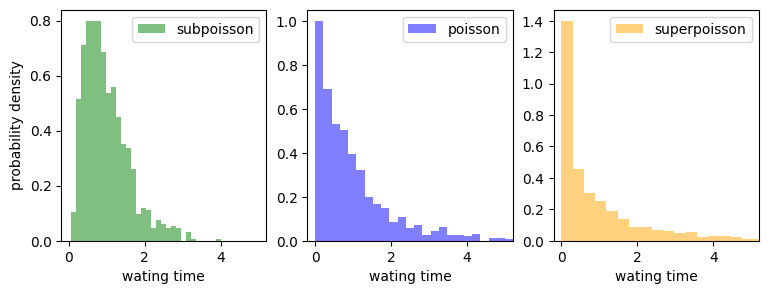

In [157]:
plt.figure(figsize=(9,3))
plt.subplot(1,3,1)
plt.hist(wtime_subpoisson,  density=True, bins=30, alpha=0.5, label='subpoisson', color='green')
plt.legend(loc='upper right')
plt.xlim([-0.2,5.2])
plt.xlabel("wating time")
plt.ylabel("probability density")
plt.subplot(1,3,2)  
plt.hist(wtime_poisson, density=True, bins=30, alpha=0.5, label='poisson', color='blue')
plt.legend(loc='upper right')
plt.xlim([-0.2,5.2])
plt.xlabel("wating time")
plt.subplot(1,3,3)
plt.hist(wtime_superpoisson,  density=True, bins=50, alpha=0.5, label='superpoisson', color='orange')
plt.legend(loc='upper right')
plt.xlim([-0.2,5.2])
plt.xlabel("wating time")

plt.show()

### Pair correlation

Calculating $g^{(2)}(\tau)$ from the spike train of photons is strait forward.  For a spike train $\{t_{1}, t_{2}, \cdots, t_{N}\}$ of $N$ photons, the number of photons separated by time difference  $\tau$ is given by

$$
n(\tau) = \sum_{i < j} \delta(\tau - t_{j}+t_{i})
$$(eq:pair_counting)

which is proportional to $g^{(2)}(\tau)$. Since neumerical calculation can't handle the delta function, we replace it with a simple rectangular function with a bin width $\Delta \tau$ and the height with the number of spikes within the bin. 

We must scale $n(\tau)$ so that  $g^{(2)}(\tau)$ is appropriately normalized.  When no correlation is present, the number of spikes within a bin does not depend on the time.  Hence the delta function is replaced with the mean counting rate $\times \Delta t$.  Then $\lim_{\tau\rightarrow\infty} n(\tau) = N \left(\frac{N}{t_\text{max}}\right)\Delta \tau$ where  $t_\text{max}$ is total measurement time.  With this normalization constant,  we have a properly normalized $g^{(2)}(\tau)$ as

$$
g^{(2)}(\tau) = \frac{n(\tau)}{n(\infty)}  = \frac{n(\tau) t_\text{max}}{N^2 \Delta \tau}
$$

The following code computes it for the above three cases.

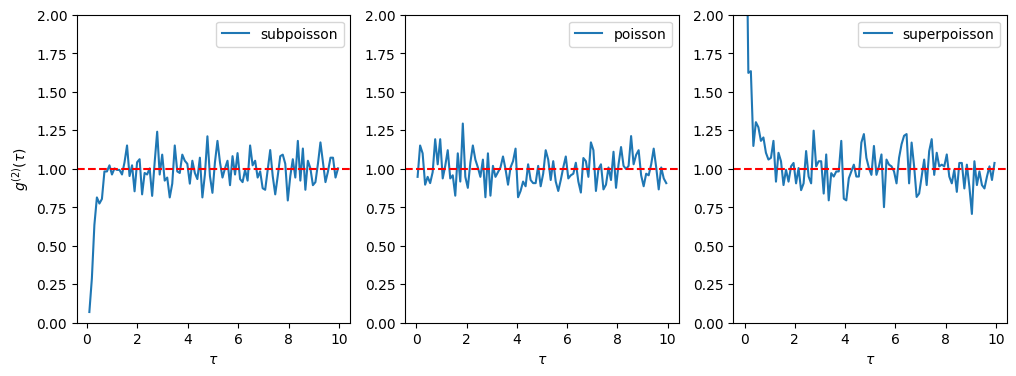

In [159]:
nbins = 100 # number of bins
tau_max = 10  # max time separation to be counted
dN = 30

# the time gaps between two spikes
def pair_times(spikes):

    time_gap = np.array([])
    i=1
    N_spikes = len(spikes)

    while i < N_spikes-dN:
        t0 = spikes[i]
        j = i+1
        while  (j > i and j < N_spikes) :
            t1 = spikes[j]
            if t1-t0 < tau_max:
                time_gap = np.append(time_gap,t1-t0)
                j += 1
            else:
                break
        i += 1
    return time_gap

pair_times_poisson = pair_times(spikes_poisson)
pair_times_subpoisson = pair_times(spikes_subpoisson)
pair_times_superpoisson = pair_times(spikes_superpoisson)

# Normalization constants
dtau = tau_max/nbins
N_spikes=len(spikes_poisson)
norm_poisson = (N_spikes-dN)*N_spikes /tmax * dtau

N_spikes=len(spikes_subpoisson)
norm_subpoisson = (N_spikes-dN)*N_spikes/tmax * dtau 

N_spikes=len(spikes_superpoisson)
norm_superpoisson =  (N_spikes-dN)*N_spikes /tmax * dtau 

# Generate normalized counts and bin center position
counts, bin = np.histogram(pair_times_poisson, bins=nbins)
n=len(bin)
x_poisson = (bin[0:n-1]+bin[1:n])/2
y_poisson=counts/norm_poisson

counts, bin = np.histogram(pair_times_subpoisson, bins=nbins)
n=len(bin)
x_subpoisson = (bin[0:n-1]+bin[1:n])/2
y_subpoisson=counts/norm_subpoisson

counts, bin = np.histogram(pair_times_superpoisson, bins=nbins)
n=len(bin)
x_superpoisson = (bin[0:n-1]+bin[1:n])/2
y_superpoisson=counts/norm_superpoisson

# plot the results
plt.figure(figsize=(12, 4))
plt.subplot(1,3,1)
plt.ylim([0,2])
plt.plot(x_subpoisson,y_subpoisson,label="subpoisson")
plt.legend(loc='upper right')
plt.xlabel(r"$\tau$")
plt.ylabel(r"$g^{(2)}(\tau)$")
plt.axhline(y=1, color='r', linestyle='--')

plt.subplot(1,3,2)
plt.ylim([0,2])
plt.plot(x_poisson,y_poisson,label='poisson')
plt.legend(loc='upper right')
plt.xlabel(r"$\tau$")
plt.axhline(y=1, color='r', linestyle='--')

plt.subplot(1,3,3)
plt.ylim([0,2])
plt.plot(x_superpoisson,y_superpoisson,label="superpoisson")
plt.legend(loc='upper right')
plt.xlabel(r"$\tau$")
plt.axhline(y=1, color='r', linestyle='--')

plt.show()

While the plot is still noisy due to insufficient sampling, the signature of three statistical types is very clear.  The poisson process shows no sign of correlation. While the superpoisson process exhibits positive correlation near $\tau=0$, suggesting bunching, the subpoisson process shows negative correlation, corresponding to anti-bunching.